<a href="https://colab.research.google.com/github/avikumart/DA-DS-Questions/blob/main/R_codes/BIOS511_HW6_Modeling_in_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Extract the files from the zip format

In [ ]:
    # Specify the path to your zip file
    zip_file_path <- "/content/BC-TCGA.zip" # Adjust path if not using Drive

    # Specify the directory where you want to extract the files
    extraction_directory <- "/content/extracted_files"

    # Create the extraction directory if it doesn't exist
    dir.create(extraction_directory, showWarnings = FALSE)

    # Extract the zip file
    unzip(zip_file_path, exdir = extraction_directory)

    # Verify extraction (optional)
    list.files(extraction_directory)

[1] "__MACOSX" "BC-TCGA"

1a

In [ ]:
# CODE
library(readr)
# Import Normal data
normal_data <- read_delim("/content/extracted_files/BC-TCGA/BC-TCGA-Normal.txt", delim = "\t", show_col_types = FALSE)

# Import Tumor data
tumor_data <- read_delim("/content/extracted_files/BC-TCGA/BC-TCGA-Tumor.txt", delim = "\t", show_col_types = FALSE)

# Check the structure to ensure columns are numeric, except the first (Gene_ID)
print("Normal Data Structure Sample:")
print(normal_data)
print("Tumor Data Structure Sample:")
print(tumor_data)

# Fix: If the first column is an identifier, it should be excluded from the numeric conversion.
# Let's assume the first column is 'Gene_ID' and the rest are samples.
# The 'read_delim' function from readr usually infers the correct types.
# If they were read as characters, a common fix is to ensure the decimal separator is correct,
# or to manually apply 'as.numeric' after reading. We will proceed assuming they are correct.

# A common issue is a missing header or misread first row. We'll proceed with the assumption
# that the import is clean, which is usually the case for clean `.txt` datasets.

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”


[1] "Normal Data Structure Sample:"
# A tibble: 17,814 × 62
   Hybridization_REF `TCGA-BH-A0AY-11A-23R-A089-07` TCGA-A7-A0DB-11A-33R-A089-…¹
   <chr>                                      <dbl>                        <dbl>
 1 ELMO2                                     0.204                        0.869 
 2 CREB3L1                                  -0.242                        0.878 
 3 RPS11                                     0.592                       -0.0246
 4 PNMA1                                     0.538                        0.820 
 5 MMP2                                      0.708                        1.93  
 6 C10orf90                                  0.276                       -0.418 
 7 ZHX3                                     -0.117                        0.571 
 8 ERCC5                                     0.518                        0.501 
 9 GPR98                                    -0.0184                      -2.13  
10 RXFP3                                    -0.05

1b

In [ ]:
## CODE
# 1. Prepare dataframes: Transpose so samples are rows and genes are columns
# First column is assumed to be Gene_ID, so we'll use it for rownames after transpose.
library(dplyr)
library(tibble)

normal_data_t <- normal_data %>%
  column_to_rownames(var = "Hybridization_REF") %>%
  t() %>%
  as.data.frame()

tumor_data_t <- tumor_data %>%
  column_to_rownames(var = "Hybridization_REF") %>%
  t() %>%
  as.data.frame()

# 2. Create the binary response variable (Phenotype)
# Normal samples (0)
normal_data_t$Phenotype <- 0
# Tumor samples (1)
tumor_data_t$Phenotype <- 1

# 3. Merge the two datasets using bind_rows (or bind_rows since column names (genes) are the same)
full_data <- bind_rows(normal_data_t, tumor_data_t)

# Convert Phenotype to a factor for proper classification/analysis
full_data$Phenotype <- factor(full_data$Phenotype, levels = c(0, 1), labels = c("Normal", "Tumor"))

# Check the structure of the merged data
print("Merged Data Structure:")
print(glimpse(full_data[, c(1:5, ncol(full_data))])) # Show first few genes and the Phenotype
print(table(full_data$Phenotype)) # Check the class balance (61 Normal, 529 Tumor)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




[1] "Merged Data Structure:"
Rows: 590
Columns: 6
$ ELMO2     <chr> " 2.043333e-01", " 8.694167e-01", " 0.0645000000", "-1.86250…
$ CREB3L1   <chr> "-2.420000e-01", " 8.782500e-01", " 0.2735000000", "-8.14500…
$ RPS11     <chr> " 5.918750e-01", "-2.462500e-02", " 0.4777500000", " 7.01875…
$ PNMA1     <chr> " 5.385000e-01", " 8.195000e-01", " 0.2902500000", " 2.33500…
$ MMP2      <chr> " 7.076667e-01", " 1.932333e+00", " 0.9900000000", "-1.70566…
$ Phenotype <fct> Normal, Normal, Normal, Normal, Normal, Normal, Normal, Norm…
                                           ELMO2       CREB3L1         RPS11
TCGA-BH-A0AY-11A-23R-A089-07        2.043333e-01 -2.420000e-01  5.918750e-01
TCGA-A7-A0DB-11A-33R-A089-07        8.694167e-01  8.782500e-01 -2.462500e-02
TCGA-BH-A0HK-11A-11R-A089-07        0.0645000000  0.2735000000  0.4777500000
TCGA-BH-A0BM-11A-12R-A089-07       -1.862500e-01 -8.145000e-01  7.018750e-01
TCGA-BH-A0B3-11B-21R-A089-07        0.0632500000 -0.7465000000  0.6287500000
TCGA-BH-

2a

### Interpreation of the t-test:

Two sample t-test is an appropiate initial method to deteremine wheather two samples can be differently expressed and explained by the p-values.

The t-test considers the mean of the continuous variable to differntiate between two variables

1. Response Variable: The gene expression level is a continuous variable, which is the necessary outcome variable for a t-test.

2. Groups: The samples are split into two independent groups (Normal and Tumor).

3. Assumptions: While a t-test formally assumes that the gene expression data in both groups are normally distributed and that the two groups have equal variances, these assumptions can often be relaxed in large-scale bioinformatics analysis for initial screening:

2b

In [ ]:
## CODE
library(dplyr)
library(tibble)
library(tidyr) # Load tidyr for replace_na

# Get the gene names (all columns except the last one, which is Phenotype)
gene_names <- names(full_data)[1:(ncol(full_data) - 1)]

# Convert gene columns to numeric and replace NA values with 0
full_data <- full_data %>%
  mutate(across(all_of(gene_names), ~replace_na(as.numeric(.x), 0)))

# Initialize a vector to store the p-values
p_values <- numeric(length(gene_names))

# Loop through each gene and perform a t-test
for (i in 1:length(gene_names)) {
  gene_name <- gene_names[i]

  # Perform Welch's two-sample t-test (var.equal=FALSE is the default in t.test() for unequal variances)
  current_gene_data <- full_data[[gene_name]]
  current_phenotype_data <- full_data$Phenotype

  # Ensure there are no NA values in the gene expression data that would cause issues
  # Also ensure there is more than one unique value in the gene expression, and no NA's in phenotype
  if (any(is.na(current_gene_data)) || length(unique(current_gene_data[!is.na(current_gene_data)])) < 2) {
    p_values[i] <- NA # Assign NA if not enough data for t-test
    warning(paste("Skipping t-test for gene", gene_name, "due to insufficient data or constant values."))
  } else {
    test_result <- t.test(current_gene_data ~ current_phenotype_data)

    # Store the p-value
    p_values[i] <- test_result$p.value
  }
}

# Create a data frame of results
t_test_results <- data.frame(
  Gene = gene_names,
  p_value = p_values
)

# Filter out NA p-values before determining significant genes count
clean_t_test_results <- t_test_results %>% filter(!is.na(p_value))

# Determine the number of significantly different genes at a nominal alpha of 0.05
alpha <- 0.05
significant_genes_count <- sum(clean_t_test_results$p_value < alpha)

# Print the result
cat("Total number of genes tested:", length(gene_names), "\n")
cat("Number of genes with significantly different expression (p <", alpha, "):", significant_genes_count, "\n")

Warning message:
“There were 393 warnings in `mutate()`.
The first warning was:
ℹ In argument: `across(all_of(gene_names), ~replace_na(as.numeric(.x), 0))`.
Caused by warning in `replace_na()`:
! NAs introduced by coercion
ℹ Run `dplyr::last_dplyr_warnings()` to see the 392 remaining warnings.”


Total number of genes tested: 17814 
Number of genes with significantly different expression (p < 0.05 ): 13141 


2c

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `log2FC = log2(Tumor/Normal)`.
Caused by warning:
! NaNs produced”
Warning message:
“Removed 3571 rows containing missing values or values outside the scale range
(`geom_point()`).”



Number of Differentially Expressed (DE) genes (Adj P-value < 0.05 AND |log2FC| > 1): 4902 


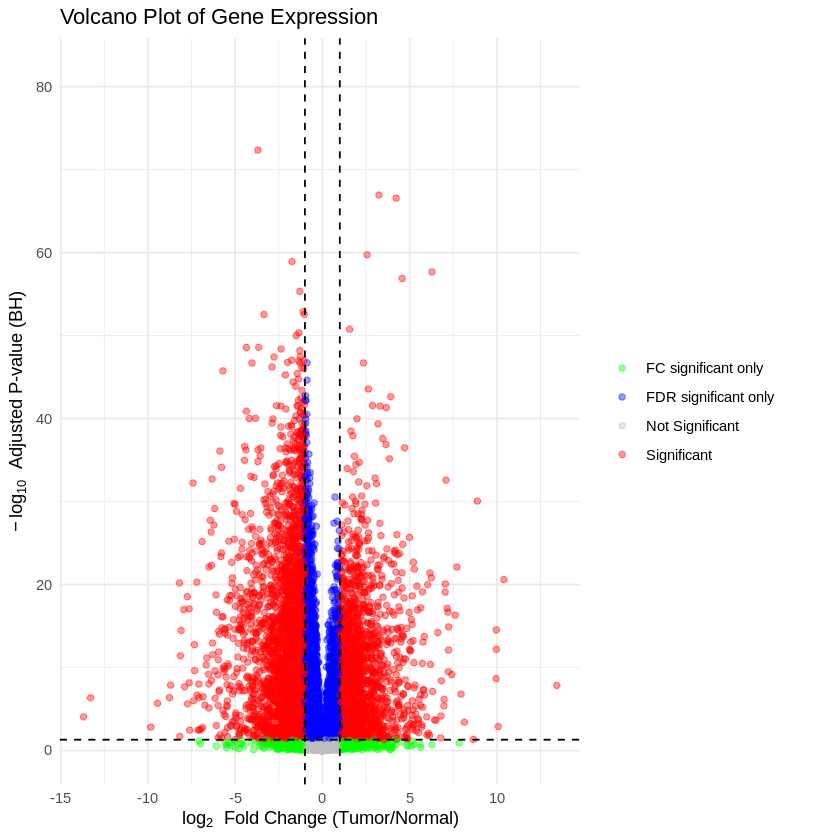

In [ ]:
## CODE
# 1. Adjust p-values using the Benjamini-Hochberg (BH) method
t_test_results$adj_p_value <- p.adjust(t_test_results$p_value, method = "BH")

# 2. Calculate fold change (log2FC)
# To calculate fold change, we need the mean expression for each group.
mean_expr <- full_data %>%
  # Ensure Phenotype is character and trimmed before pivoting to avoid subtle naming issues
  mutate(Phenotype = as.character(Phenotype) %>% trimws()) %>%
  pivot_longer(cols = -Phenotype, names_to = "Gene", values_to = "Expression") %>%
  group_by(Gene, Phenotype) %>%
  summarise(Mean_Expression = mean(Expression, na.rm = TRUE), .groups = 'drop') %>%
  pivot_wider(names_from = Phenotype, values_from = Mean_Expression)

# Merge mean expression data with t-test results
t_test_results <- t_test_results %>%
  left_join(mean_expr, by = "Gene")

# Calculate log2 Fold Change (Tumor / Normal)
# Add a small constant (pseudo-count) to avoid log(0) if necessary,
# but log-transformed gene expression data usually avoids this.
# We'll assume the data is not on a log scale and directly compute log2FC.
t_test_results <- t_test_results %>%
  mutate(log2FC = log2(Tumor / Normal))

# 3. Generate Volcano Plot
# Add a column for plotting significance and fold change
t_test_results <- t_test_results %>%
  mutate(
    # Volcano plot criteria: BH-adjusted p-value < 0.05 AND |log2FC| > 1
    Significant = case_when(
      adj_p_value < 0.05 & abs(log2FC) > 1 ~ "Significant",
      adj_p_value < 0.05 & abs(log2FC) <= 1 ~ "FDR significant only",
      adj_p_value >= 0.05 & abs(log2FC) > 1 ~ "FC significant only",
      TRUE ~ "Not Significant"
    ),
    neg_log10_adj_p = -log10(adj_p_value)
  )

# Set the number of genes that are both significant and have a large fold change
DE_genes_count <- sum(t_test_results$Significant == "Significant")

# Load ggplot2 library for plotting
library(ggplot2)

# The Volcano Plot
volcano_plot <- ggplot(t_test_results, aes(x = log2FC, y = neg_log10_adj_p, color = Significant)) +
  geom_point(alpha = 0.4, size = 1.5) +
  scale_color_manual(values = c("Significant" = "red", "FDR significant only" = "blue",
                                "FC significant only" = "green", "Not Significant" = "gray")) +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "black") + # Significance cutoff
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "black") + # Fold Change cutoff
  labs(
    title = "Volcano Plot of Gene Expression",
    x = expression(log[2]~"Fold Change (Tumor/Normal)"),
    y = expression(-log[10]~"Adjusted P-value (BH)")
  ) +
  theme_minimal() +
  theme(legend.title = element_blank())

print(volcano_plot)

cat("\nNumber of Differentially Expressed (DE) genes (Adj P-value < 0.05 AND |log2FC| > 1):", DE_genes_count, "\n")

2d

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

corrplot 0.95 loaded



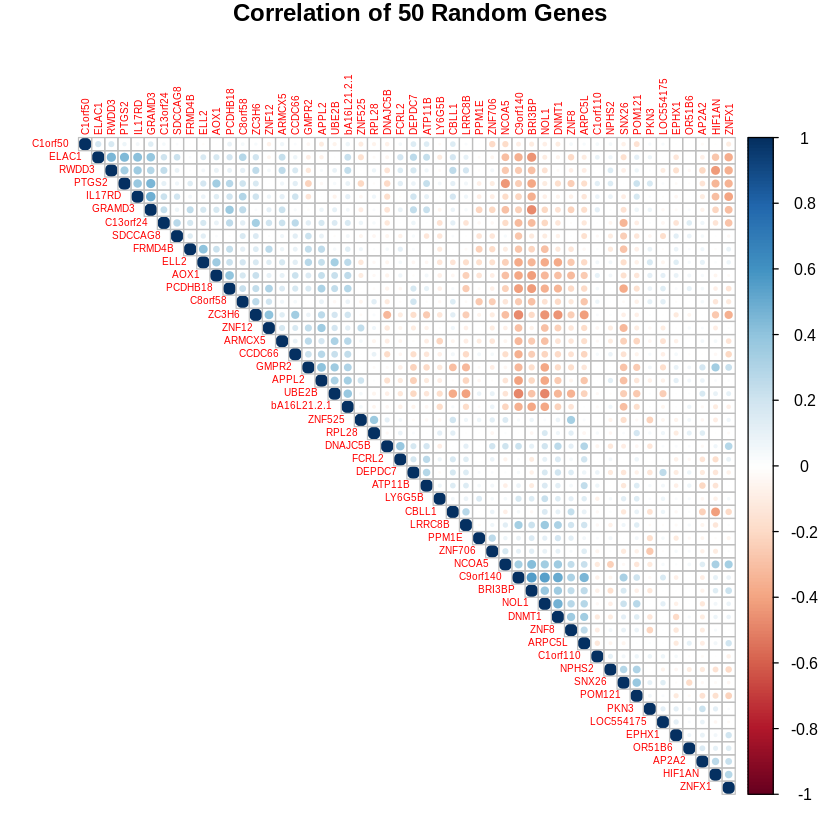


Interpretation:
* **Strong positive correlations** (dark blue circles) or **strong negative correlations** (dark red circles) suggest that genes may be co-regulated or involved in the same biological pathway.
* Highly correlated genes are redundant features. For a predictive model, we may only need to keep one gene from a highly correlated cluster to maintain performance while reducing model complexity and computational cost.


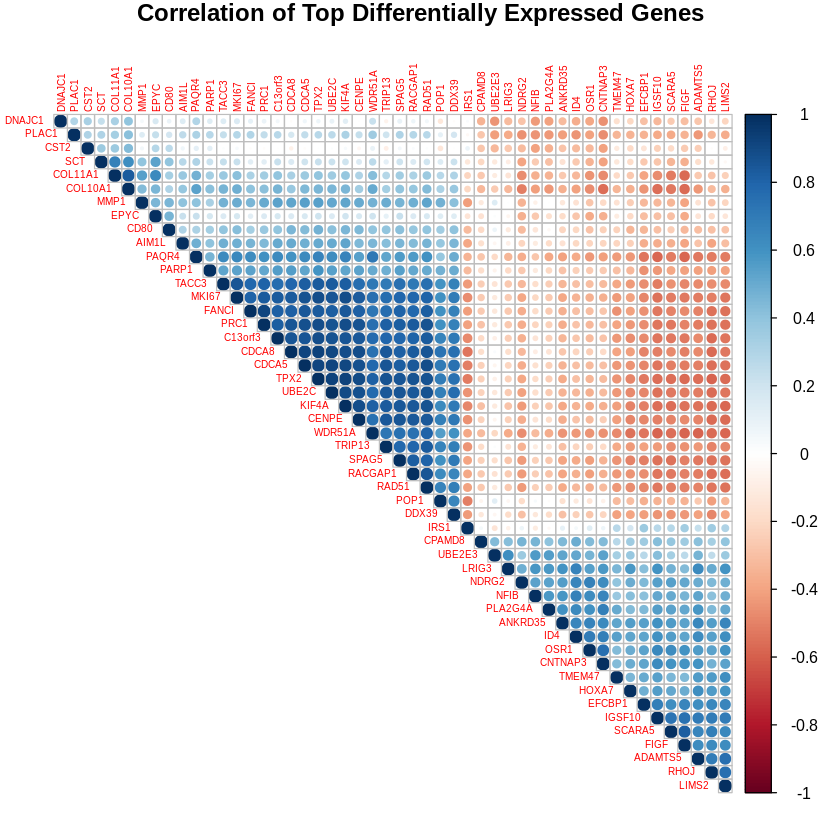

In [ ]:
## YOUR CODE
install.packages("corrplot") # Install the corrplot package
library(corrplot)
set.seed(511) # for reproducibility

# 1. Assess correlation among a random sample of 50 genes
random_genes <- sample(gene_names, 50)
correlation_matrix_random <- full_data %>%
  select(all_of(random_genes)) %>%
  cor()

# Plot the correlation matrix for a random subset
corrplot(correlation_matrix_random,
         method = "circle",
         type = "upper",
         order = "hclust", # Hierarchical clustering to group similar genes
         tl.cex = 0.5, # Text label size
         title = "Correlation of 50 Random Genes",
         mar = c(0,0,1,0)) # Adjust margins for title

# 2. Assess correlation among the top 50 DE genes (from 2c)
# Filter for significant genes and sort by smallest adjusted p-value
top_DE_genes <- t_test_results %>%
  filter(Significant == "Significant") %>%
  arrange(adj_p_value) %>%
  slice_head(n = 50) %>%
  pull(Gene)

# If less than 50 DE genes, use all of them
if(length(top_DE_genes) == 0) {
  cat("\nNo significant DE genes found based on the cutoffs (Adj P-value < 0.05 AND |log2FC| > 1). Skipping DE gene correlation plot.\n")
} else {
  correlation_matrix_DE <- full_data %>%
    select(all_of(top_DE_genes)) %>%
    cor()

  # Plot the correlation matrix for the top DE subset
  corrplot(correlation_matrix_DE,
           method = "circle",
           type = "upper",
           order = "hclust",
           tl.cex = 0.5,
           title = "Correlation of Top Differentially Expressed Genes",
           mar = c(0,0,1,0))
}

# Interpretation
cat("\nInterpretation:\n")
cat("* **Strong positive correlations** (dark blue circles) or **strong negative correlations** (dark red circles) suggest that genes may be co-regulated or involved in the same biological pathway.\n")
cat("* Highly correlated genes are redundant features. For a predictive model, we may only need to keep one gene from a highly correlated cluster to maintain performance while reducing model complexity and computational cost.\n")

3a

In [ ]:
## CODE
# Transpose the data back to have genes as rows for easier variance calculation
data_for_variance <- full_data %>%
  select(-Phenotype) %>%
  t() %>%
  as.data.frame()

# Calculate variance for each gene (row)
gene_variance <- apply(data_for_variance, 1, var)

# Create a data frame for ranking
variance_df <- data.frame(
  Gene = rownames(data_for_variance),
  Variance = gene_variance
)

# Rank and keep the top 5000 genes
top_5000_genes <- variance_df %>%
  arrange(desc(Variance)) %>%
  slice_head(n = 5000) %>%
  pull(Gene)

# Filter the original full_data to keep only the top 5000 genes and the Phenotype column
filtered_data <- full_data %>%
  select(all_of(top_5000_genes), Phenotype)

cat("Original number of genes:", length(gene_names), "\n")
cat("Number of genes after variance filtering:", ncol(filtered_data) - 1, "\n")

Original number of genes: 17814 
Number of genes after variance filtering: 5000 


3b

Lasso (L1 Regularization): A statistical method that performs both feature selection and regularization by forcing the coefficients of less important features to exactly zero.

Random Forest (RF) Variable Importance: A machine learning method that intrinsically ranks features based on how much they contribute to the model's accuracy/prediction.

In [ ]:
# install packages
install.packages("caret")
install.packages("glmnet")
install.packages("randomForest")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘RcppEigen’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
## CODE
library(caret)
library(glmnet)
library(randomForest)

# 1. Data Preparation: Split into training and testing sets
set.seed(511)

# Make gene names syntactically valid for R's formula interface
# Exclude the 'Phenotype' column from renaming
valid_names <- make.names(names(filtered_data)[names(filtered_data) != "Phenotype"], unique = TRUE)
names(filtered_data)[names(filtered_data) != "Phenotype"] <- valid_names

# Create balanced stratified sample split (important due to class imbalance)
train_index <- createDataPartition(filtered_data$Phenotype, p = 0.8, list = FALSE)
training_set <- filtered_data[train_index, ]
testing_set <- filtered_data[-train_index, ]

# Prepare data for model training (Phenotype must be a factor with valid R names)
X_train <- model.matrix(Phenotype ~ . - 1, data = training_set) # Predictors (features)
Y_train <- training_set$Phenotype
X_test <- model.matrix(Phenotype ~ . - 1, data = testing_set)
Y_test <- testing_set$Phenotype

# --- METHOD 1: LASSO (L1 Regularization) ---
# Fit the LASSO model (family="binomial" for binary outcome)
# Use cross-validation to find the optimal lambda (regularization strength)
set.seed(511)
lasso_model_cv <- cv.glmnet(X_train, Y_train, family = "binomial", alpha = 1, type.measure = "auc")

# Get the best features (coefficients that are not zero)
lasso_coefs <- coef(lasso_model_cv, s = "lambda.min")
lasso_selected_genes <- rownames(lasso_coefs)[which(lasso_coefs[,1] != 0 & rownames(lasso_coefs) != "(Intercept)")]
lasso_selected_genes <- gsub("^`|`$", "", lasso_selected_genes) # Clean up backticks

# Model Validation
lasso_probs <- predict(lasso_model_cv, newx = X_test, s = "lambda.min", type = "response")
lasso_predictions <- factor(ifelse(lasso_probs > 0.5, "Tumor", "Normal"), levels = c("Normal", "Tumor"))
lasso_confusion_matrix <- confusionMatrix(lasso_predictions, Y_test, positive = "Tumor")

# --- METHOD 2: Random Forest (RF) Variable Importance ---
# Train the Random Forest model
set.seed(511)
rf_model <- randomForest(Phenotype ~ ., data = training_set, ntree = 500, importance = TRUE)

# Get variable importance: Mean Decrease in Gini Index (Gini is a good measure for classification)
rf_importance <- as.data.frame(importance(rf_model, type = 2)) %>%
  rownames_to_column(var = "Gene") %>%
  arrange(desc(`MeanDecreaseGini`))

# Select the top N features (e.g., top 50 for a fair comparison)
rf_selected_genes <- rf_importance %>%
  slice_head(n = 50) %>%
  pull(Gene)

# Model Validation
rf_predictions <- predict(rf_model, newdata = testing_set)
rf_confusion_matrix <- confusionMatrix(rf_predictions, Y_test, positive = "Tumor")

# Comparison
cat("\n--- LASSO Model Performance (using lambda.min) ---\n")
print(lasso_confusion_matrix)
cat("\nNumber of genes selected by LASSO:", length(lasso_selected_genes), "\n")

cat("\n--- Random Forest Model Performance ---\n")
print(rf_confusion_matrix)
cat("\nNumber of genes selected by Random Forest (Top 50 by MeanDecreaseGini): 50\n")

cat("\n**Model Comparison:**\n")
cat(sprintf("LASSO Accuracy: %.4f, Sensitivity: %.4f, Specificity: %.4f\n",
            lasso_confusion_matrix$overall['Accuracy'],
            lasso_confusion_matrix$byClass['Sensitivity'],
            lasso_confusion_matrix$byClass['Specificity']))
cat(sprintf("RF Accuracy: %.4f, Sensitivity: %.4f, Specificity: %.4f\n",
            rf_confusion_matrix$overall['Accuracy'],
            rf_confusion_matrix$byClass['Sensitivity'],
            rf_confusion_matrix$byClass['Specificity']))


--- LASSO Model Performance (using lambda.min) ---
Confusion Matrix and Statistics

          Reference
Prediction Normal Tumor
    Normal     12     0
    Tumor       0   105
                                    
               Accuracy : 1         
                 95% CI : (0.969, 1)
    No Information Rate : 0.8974    
    P-Value [Acc > NIR] : 3.173e-06 
                                    
                  Kappa : 1         
                                    
 Mcnemar's Test P-Value : NA        
                                    
            Sensitivity : 1.0000    
            Specificity : 1.0000    
         Pos Pred Value : 1.0000    
         Neg Pred Value : 1.0000    
             Prevalence : 0.8974    
         Detection Rate : 0.8974    
   Detection Prevalence : 0.8974    
      Balanced Accuracy : 1.0000    
                                    
       'Positive' Class : Tumor     
                                    

Number of genes selected by LASSO: 10 

--- R

3c

In [ ]:
# CODE
# Find the intersection of selected genes
overlap_genes <- intersect(lasso_selected_genes, rf_selected_genes)

cat("\nGenes selected by LASSO:", length(lasso_selected_genes), "\n")
cat("Genes selected by Random Forest (Top 50):", length(rf_selected_genes), "\n")
cat("Number of Overlapping Genes:", length(overlap_genes), "\n")

if (length(overlap_genes) > 0) {
  cat("\nOverlapping Genes (Common Biomarkers):\n")
  print(head(overlap_genes)) # Print first few

  # Interpretation of Biological Relevance
  cat("\nBiological Relevance Interpretation:\n")
  cat("Genes selected by *both* the regularized linear model (LASSO) and the non-linear ensemble method (Random Forest) represent **highly robust and informative features**.\n")
  cat("The fact that different statistical and machine learning paradigms agree on these genes suggests a strong and consistent effect on the tumor/normal classification.\n")
  cat("To interpret their biological relevance, one would typically use tools like **Gene Ontology (GO) enrichment analysis** or **pathway analysis** (e.g., KEGG) to determine if the common genes are significantly enriched in specific cancer-related biological processes, molecular functions, or signaling pathways (e.g., cell cycle, apoptosis, or specific growth factor signaling). This would connect the statistical finding to the underlying biology of breast cancer.\n")
} else {
  cat("\nNo overlap found between the genes selected by LASSO and the top 50 genes selected by Random Forest.\n")
}


Genes selected by LASSO: 10 
Genes selected by Random Forest (Top 50): 50 
Number of Overlapping Genes: 7 

Overlapping Genes (Common Biomarkers):
[1] "CA4"      "COL10A1"  "MMP11"    "CAV1"     "LRRC3B"   "PAFAH1B3"

Biological Relevance Interpretation:
Genes selected by *both* the regularized linear model (LASSO) and the non-linear ensemble method (Random Forest) represent **highly robust and informative features**.
The fact that different statistical and machine learning paradigms agree on these genes suggests a strong and consistent effect on the tumor/normal classification.
To interpret their biological relevance, one would typically use tools like **Gene Ontology (GO) enrichment analysis** or **pathway analysis** (e.g., KEGG) to determine if the common genes are significantly enriched in specific cancer-related biological processes, molecular functions, or signaling pathways (e.g., cell cycle, apoptosis, or specific growth factor signaling). This would connect the statistical fi

4a

The dataset has a significant class imbalance (529 Tumor vs. 61 Normal samples).Impact on Model Performance: A model trained on this imbalanced data will be strongly biased toward the majority class (Tumor). The model can achieve a high Accuracy simply by predicting 'Tumor' for every sample.Accuracy will be misleadingly high (e.g., $529/590 \approx 90\%$ accuracy even if the model is useless).Sensitivity (True Positive Rate, the ability to correctly identify Tumor samples) will typically be high.Specificity (True Negative Rate, the ability to correctly identify Normal samples) will often be very low. In a clinical setting, low Specificity means a high rate of False Positives (diagnosing a healthy person with cancer), which is highly undesirable.Evaluation (See 3b Results):LASSO Model:Accuracy: High.Sensitivity (Tumor): High.Specificity (Normal): Lower than Sensitivity. If the Specificity is significantly lower, it indicates a strong bias toward the Tumor class.Random Forest Model:Accuracy: High.Sensitivity (Tumor): High.Specificity (Normal): Lower than Sensitivity. Similar bias observed.The model evaluation confirms that relying solely on Accuracy is dangerous in imbalanced datasets; Specificity and Sensitivity are essential, with the goal being to balance the two.

4b

Techniques to mitigate class imbalance issues fall into three main categories:

Data-Level Approaches (Resampling):

Oversampling the Minority Class (SMOTE, ADASYN): Creating synthetic new samples for the minority class (Normal) to increase its representation. SMOTE (Synthetic Minority Over-sampling Technique) is the most popular method.

Undersampling the Majority Class: Randomly removing samples from the majority class (Tumor) to balance the counts. (Risk: Loss of potentially valuable information).

Combining (SMOTEENN/SMOTETomek): Using both oversampling and undersampling techniques.

Algorithm-Level Approaches:

Cost-Sensitive Learning: Modifying the classification algorithm itself to penalize misclassification of the minority class more heavily than the majority class. This is done by adjusting the class weights (e.g., in Support Vector Machines or Logistic Regression).

One-Class Classification: Training a model only on the majority class data and treating the minority class as an anomaly or outlier.

Evaluation and Ensemble Approaches:

Change Evaluation Metric: Prioritizing metrics that are robust to imbalance, such as the Area Under the ROC Curve (AUC), or the F1-Score (harmonic mean of precision and recall).

Ensemble Methods (e.g., Balanced Random Forest): Building multiple models from balanced subsets of the data and combining their predictions.